# <center>Feedforward and Backpropagation</center>
## <center>Inclass Project 2 - MA4144</center>

This project contains 10 tasks/questions to be completed, some require written answers. Open a markdown cell below the respective question that require written answers and provide (type) your answers. Questions that required written answers are given in blue fonts. Almost all written questions are open ended, they do not have a correct or wrong answer. You are free to give your opinions, but please provide related answers within the context.

After finishing project run the entire notebook once and **save the notebook as a pdf** (File menu -> Save and Export Notebook As -> PDF). You are **required to upload this PDF on moodle**.

***

## Outline of the project

The aim of the project is to build a Multi Layer perceptron (MLP) model from scratch for binary classification. That is given an input $x$ output the associated class label $0$ or $1$.

In particular, we will classify images of handwritten digits ($0, 1, 2, \cdots, 9$). For example, given a set of handwritten digit images that only contain two digits (Eg: $1$ and $5$) the model will classify the images based on the written digit.

For this we will use the MNIST dataset (collection of $28 \times 28$ images of handwritten digits) - you can find additional information about MNIST [here](https://en.wikipedia.org/wiki/MNIST_database).

<img src="https://upload.wikimedia.org/wikipedia/commons/f/f7/MnistExamplesModified.png" width="250">

***


Use the below cell to use any include any imports

In [37]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

## Section 1: Preparing the data

In [38]:
#Load the dataset as training and testing, then print out the shapes of the data matrices

(train_X, train_y), (test_X, test_y) = mnist.load_data()
print(train_X.shape)
print(test_X.shape)
print(train_y.shape)
print(test_y.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


**Q1.** In the following cell write code to display $5$ random images in train_X and it's corresponding label in train_y. Each time it is run, you should get a different set of images. The imshow function in the matplotlib library could be useful. Display them as [grayscale images](https://en.wikipedia.org/wiki/Grayscale).

Displaying 5 random images from train_X dataset

Index number:  2274


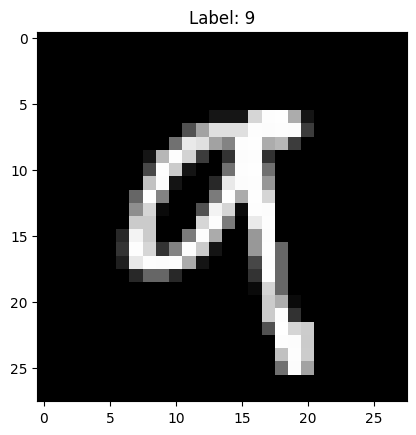



Index number:  10611


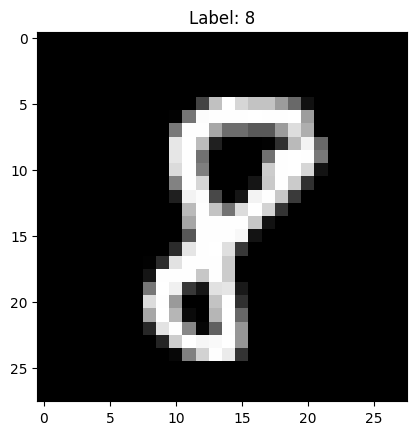



Index number:  54833


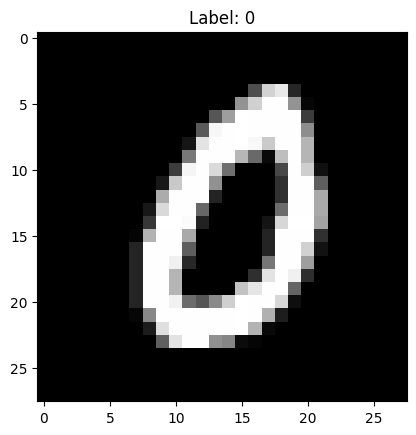



Index number:  3563


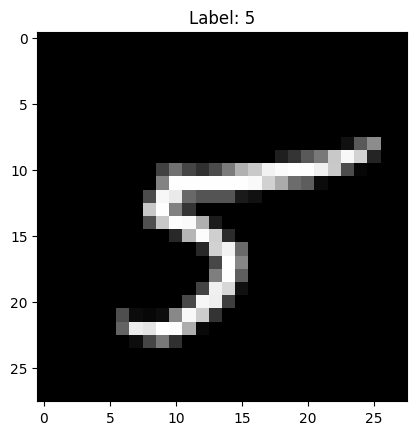



Index number:  31986


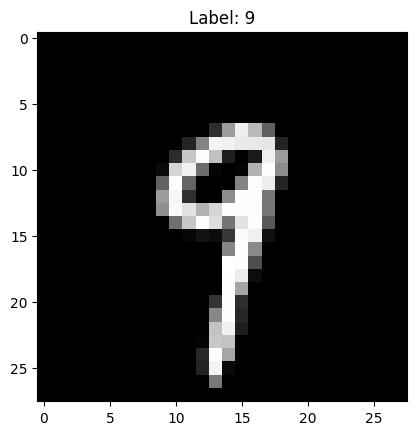

In [39]:
#TODO Code to display 5 random handritten images from train_X and corresponting labels from train_y
print("Displaying 5 random images from train_X dataset\n")
for i in range(5):
    index = np.random.randint(0, train_X.shape[0])
    print("Index number: ", index)
    plt.imshow(train_X[index], cmap='gray')
    plt.title("Label: " + str(train_y[index]))
    plt.show()
    print("\n")
    

**Q2.** Given two digits $d_1$ and $d_2$, both between $0$ and $9$, in the following cell fill in the function body to extract all the samples corresponding to $d_1$ or $d_2$ only, from the dataset $X$ and labels $y$. You can use the labels $y$ to filter the dataset. Assume that the $i$th image $X[i]$ in $X$ is given by $y[i]$. The function should return the extracted samples $X_{extracted}$ and corresponding labels $y_{extracted}$. Avoid using for loops as much as possible, infact you do not need any for loops. numpy.where function should be useful.

In [40]:
def extract_digits(X, y, d1, d2):

    assert d1 in range(0, 10), "d1 should be a number between 0 and 9 inclusive"
    assert d2 in range(0, 10), "d2 should be a number between 0 and 9 inclusive"
    
    # TODO
    # Extract only the digits d1 and d2 from the dataset X and the labels y
    d1_indices = np.where(y == d1)
    d2_indices = np.where(y == d2)
    
    print("first 3 d1_indices: ", d1_indices[0][:3])
    # display the first 3 indices of d1_indices in one row
    # for i in range(3):
    #     index = d1_indices[0][i]
    #     print("Index number: ", index)
    #     plt.imshow(X[index], cmap='gray')
    #     plt.title("Label: " + str(y[index]))
    #     plt.show()
    #     print("\n")
        
    
    
    print("first 3 d2_indices: ", d2_indices[0][:3])
    # display the first 3 indices of d1_indices
    # for i in range(3):
    #     index = d2_indices[0][i]
    #     print("Index number: ", index)
    #     plt.imshow(X[index], cmap='gray')
    #     plt.title("Label: " + str(y[index]))
    #     plt.show()
    #     print("\n")
    
    
    X_extracted = np.concatenate((X[d1_indices], X[d2_indices]))
    y_extracted = np.concatenate((y[d1_indices], y[d2_indices]))
        
    # Shuffle the data
    indices = np.arange(X_extracted.shape[0])
    np.random.shuffle(indices)
    X_extracted = X_extracted[indices]
    y_extracted = y_extracted[indices]
    
    return (X_extracted, y_extracted)

In [41]:
# calling the function to extract digits 0 and 1 (for example)
X_extracted, y_extracted = extract_digits(train_X, train_y, 0, 1)

first 3 d1_indices:  [ 1 21 34]
first 3 d2_indices:  [3 6 8]


**Q3.** Both the training dataset train_X and test_y is a 3 dimensional numpy array, each image occupies 2 dimensions. For convenience of processing data we usually comvert each $28 \times 28$ image matrix to a vector with $784$ entries. We call this process **vectorize images**.

Once we vectorize the images, the vectorized data set would be structured as follows: $i$th row will correspond to a single image and $j$th column will correspond to the $j$th pixel value of each vectorized image. However going along with the convention we discussed in the lecture, the input to the MLP model will require that the columns correspond to individual images. Hence we also require a transpose of the vectorized results.

The pixel values in the images will range from $0$ to $255$. Normalize the pixel values between $0$ and $1$, by dividing each pixel value of each image by the maximum pixel value of that image. Simply divide each column of the resulting matrix above by the max of each column. 

<center><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTdN_8m9FEqjqAB07obTmB6gNc7S2rSoGBYaA&s"></center>

Given a dataset $X$ of size $N \times 28 \times 28$, in the following cell fill in the function to do the following in order;
1. Vectorize the dataset resulting in dataset of size $N \times 784$.
2. Transpose the vectorized result.
3. Normalize the pixel values of each image.
4. Finally return the vectorized, transposed and normalized dataset $X_{transformed}$.

Again, avoid for loops, functions such as numpy.reshape, numpy.max etc should be useful.

In [42]:
print("train X data shape: ", train_X.shape)

train X data shape:  (60000, 28, 28)


In [43]:
def vectorize_images(X):

    #TODO
    # Reshape the images to vectors (vectorize the dataset)
    X_vector = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
    print("X vector shape: ", X_vector.shape)
    
    # taking traspose of the vectors
    transposed_X_vector = np.transpose(X_vector)
    print("Transposed X vector shape :", transposed_X_vector.shape)
    
    # normalizing the pixel values of each image coressponding to the maximum pixel value of its each column
    normalized_X_vector = transposed_X_vector / np.max(transposed_X_vector, axis=0)
    print("Normalized X vector shape: ", normalized_X_vector.shape)
    
    X_tranformed = normalized_X_vector

    return(X_tranformed)

In [44]:
X_tranformed = vectorize_images(X_extracted)
print("X tranformed shape: ", X_tranformed.shape)

X vector shape:  (12665, 784)
Transposed X vector shape : (784, 12665)
Normalized X vector shape:  (784, 12665)
X tranformed shape:  (784, 12665)


**Q4.** In the following cell write code to;

1. Extract images of the digits $d_1 = 1$ and $d_2 = 5$ with their corresponding labels for both the training set (train_X, train_y) and testing set (test_X, test_y) separately.
2. Then vectorize the data, tranpose the result and normlize the images.
3. Store the results after the final transformations in numpy arrays train_X_1_5, train_y_1_5, test_X_1_5, test_y_1_5
4. Our MLP will output only class labels $0$ and $1$ (not $1$ and $5$), so create numpy arrays to store the class labels as follows:
   $d_1 = 1$ -> class label = 0 and $d_2 = 5$ -> class label = 1. Store them in the arrays named train_class_1_5, test_class_1_5.

Use the above functions you implemented above to complete this task. In addtion, numpy.where could be useful. Avoid for loops as much as possible.

In [45]:
d1 = 1
d2 = 5
print("d1: ", d1)
print("d2: ", d2, "\n")

# calling the function to extract digits d1 and d2
print("Extracting digits ", d1, " and ", d2, " from the training dataset")
train_X_extracted, train_y_extracted = extract_digits(train_X, train_y, d1, d2)
print("")
print("Extracting digits ", d1, " and ", d2, " from the testing dataset")
test_X_extracted, test_y_extracted = extract_digits(test_X, test_y, d1, d2)

print("")

# Vectorize, transpose and the normalize the data
train_X_1_5 = vectorize_images(train_X_extracted)
print("train_X_1_5 tranformed shape: ", train_X_1_5.shape)
train_y_1_5 = np.where(train_y_extracted > 1, 1, 0)
print("")
test_X_1_5 = vectorize_images(test_X_extracted)
print("test_X_1_5 tranformed shape: ", test_X_1_5.shape)
test_y_1_5 = np.where(test_y_extracted > 1, 1, 0)


d1:  1
d2:  5 

Extracting digits  1  and  5  from the training dataset
first 3 d1_indices:  [3 6 8]
first 3 d2_indices:  [ 0 11 35]

Extracting digits  1  and  5  from the testing dataset
first 3 d1_indices:  [ 2  5 14]
first 3 d2_indices:  [ 8 15 23]

X vector shape:  (12163, 784)
Transposed X vector shape : (784, 12163)
Normalized X vector shape:  (784, 12163)
train_X_1_5 tranformed shape:  (784, 12163)

X vector shape:  (2027, 784)
Transposed X vector shape : (784, 2027)
Normalized X vector shape:  (784, 2027)
test_X_1_5 tranformed shape:  (784, 2027)


## Section 2: Implementing MLP from scratch with training algorithms.

Now we will implement code to build a customizable MLP model. The hidden layers will have the **Relu activation function** and the final output layer will have **Sigmoid activation function**.

**Q5.** Recall the following about the activation functions:
1. Sigmoid activation: $y = \sigma(z) = \frac{1}{1 + e^{-z}}$.
2. Derivative of Sigmoid: $y' = \sigma'(z) = \sigma(z) (1 - \sigma(z)) = y(1-y)$
3. ReLu activation: $y = ReLu(z) = max(0, z)$
4. Derivative of ReLu: $y' = ReLu'(z) = \begin{cases} 0 \; \textrm{if } z < 0 \\ 1 \; \textrm{otherwise} \end{cases} = \begin{cases} 0 \; \textrm{if } y = 0 \\ 1 \; \textrm{otherwise} \end{cases}$

In the following cell implement the functions to compute activation functions Sigmoid and ReLu given $z$ and derivatives of the Sigmoid and ReLu activation functions given $y$. Note that the input to the derivative functions is $y$ not $z$.

In practice the input will not be just single numbers, but matrices. So functions or derivatives should be applied elementwise on matrices. Again avoid for loops, use the power of numpy arrays - search for numpy's capability of doing elementwise computations.

Important: When implementing the sigmoid function make sure you handle overflows due to $e^{-z}$ being too large. To avoid you can choose to set the sigmoid value to 'the certain appropriate value' if $z$ is less than a certain good enough negative threshold. If you do not handle overflows, the entire result will be useless fince the MLP will just output Nan (not a number) for evry input at the end.

In [46]:
def sigmoid(Z):

    #TODO
    
    # handling overflow due to e^(-z) being very large
    threshold_val = np.clip(Z, -500, 500)

    sigma = 1/(1 + np.exp(-threshold_val))
 
        
    return(sigma)

def deriv_sigmoid(Y):

    #TODO
   
    sigma_prime = Y * (1 - Y)
    
    
    return(sigma_prime)

def ReLu(Z):

    #TODO
    
    relu = np.where(Z < 0, 0, Z)
    
    return(relu)

def deriv_ReLu(Y):

    #TODO
    
    relu_prime = np.where(Y == 0, 0, 1)
    
    return(relu_prime)


**Q6.** The following piece of code defines a simple MLP architecture as a Python class and subsequent initialization of a MLP model. <font color='blue'>Certain lines of code contains commented line numbers. Write a short sentence for each such line explaining its purpose. Feel free to refer to the lecture notes or any resources to answers these question. In addition, explain what the Y, Z, W variables refer to and their purpose</font>

In [47]:
class NNet:
    def __init__(self, input_size = 784, output_size = 1, batch_size = 1000, hidden_layers = [500, 250, 50]):
        
        self.Y = []
        self.Z = []
        self.W = []
        self.input_size = input_size
        self.output_size = output_size
        self.batch_size = batch_size
        self.hidden_layers = hidden_layers

        layers = [input_size] + hidden_layers + [output_size]
        L = len(hidden_layers) + 1
    
        for i in range(1, L + 1):
            self.Y.append(np.zeros((layers[i], batch_size)))                        # Line 1 
            self.Z.append(np.zeros((layers[i], batch_size)))                        # Line 2 
            self.W.append(2*(np.random.rand(layers[i], layers[i-1] + 1) - 0.5))     # Line 3 

**Answers** (to write answers edit this cell)

(i) What does the Y, Z, W variables refer to and their purpose?  
    Y, Z, W are lists of numpy arrays and there are used to store the outputs (activations) of each layer during the forward pass, the pre-activation values (input to activation functions) for each layer and the weights for each layer of the network respectively.
   
(ii) Line1: Y is a list of arrays that creates a numpy array of zeros with dimensions (layers[i] x batch_size), where layers[i] is the number of neurons in the current layer, and batch_size is the number of samples processed simultaneously.

(iii) Line2: Z is a list of arrays that creates a numpy array of zeros with dimensions (layers[i] x batch_size). These pre-activations are the values computed before applying an activation function.

(iv) Line3: W is a list of arrays of size (layers[i], layers[i-1] + 1) initialized with random values between -1 and 1 to the weight matrix (W) of the current layer.

**Q7.** Now we will implement the feedforward algorithm. Recall from the lectures that for each layer $l$ there is input $Y^{(l-1)}$ from the previous layer if $l > 1$ and input data $X$ if $l = 1$. Then we compute $Z^{(l)}$ using the weight matrix $W^{(l)}$ as follows from matrix multiplication:

$Z^{(l)} = W^{(l)} Y^{(l-1)}$

Make sure that during multiplication you add an additional row of one's to $Y^{(l-1)}$ to accommodate the bias term. However, the rows of ones should not permanently remain on $Y^{(l-1)}$. <font color='blue'>Explain what the bias term is and how adding a row of one's help with the bias terms.</font> During definition above the weight matrices are initialised to afford this extra bias term, so no change to either $Z^{(l)}$ or $W^{(l)}$ is needed.

Next compute $Y^{(l)}$, the output of layer $l$ by activation through sigmoid.

$Y^{(l)} = \sigma(Z^{(l)})$

The implemented feedforward algorithm should take in a NNet model and an input matrix $X$ and output the modified MLP model - the $Y$'s and $Z$'s computed should be stored in the model for the backpropagation algorithm.

As usual avoid for loops as much as possible, use the power of numpy. However, you may use a for loop to iterate through the layers of the model.

In [48]:
def feedforward(model, X):

    #TODO
    # print("X shape: ", X.shape)
    L = len(model.hidden_layers) + 1
    
    prev_y = X
    
    if prev_y.ndim == 1:
        prev_y = prev_y.reshape(-1,1)
    
    for l in range(L):
        prev_y = np.vstack([prev_y, np.ones((1, prev_y.shape[1]))])
        # print("prev_y shape: ", prev_y.shape)
        # print("W shape: ", model.W[l].shape)
        model.Z[l] = model.W[l] @ prev_y
        # print("Z shape: ", model.Z[l].shape)
        if l == L-1:
            model.Y[l] = sigmoid(model.Z[l])
        else:
            model.Y[l] = ReLu(model.Z[l])
            
        prev_y = model.Y[l]
       
        
    return(model)

**Answer** (to write answers edit this cell)

Explain what the bias term is and how adding a row of one's help with the bias terms.

The bias term in a neural network helps shift the activation function, allowing neurons to activate even with low or zero inputs, improving the model's flexibility.

Adding a row of ones to the input matrix during matrix multiplication simplifies incorporating the bias. It expands the input size, allowing the last column of the weight matrix to represent the bias. This way, the bias is automatically included in the computation without needing separate handling, making the process efficient and clean.

**Q8.** Now we will implement the backpropagation algorithm. The cost function $C$ at the end is given by the square loss.

$C = \frac{1}{2} ||Y^{(L)} - Y||^{2}$, where $Y^{(L)}$ is the final output vector of the feedforward algorithm and $Y$ is the actual label vector associated with the input $X$.

At each layer $l = 1, 2, \cdots, L$ we compute the following (note that the gradients are matrices with the same dimensions as the variable to which we derivating with respect to):

1. Gradient of $C$ with respect to $Z^{(l)}$ as <br> $\frac{\partial C}{\partial Z^{(l)}} = deriv(A^{(l)}(Z^{(l)})) \odot \frac{\partial C}{\partial Y^{(L)}} $, <br> where $A^{(l)}$ is the activation function of the $l$th layer, and we use the derivative of that here. The $\odot$ refers to the elementwise multiplication.

2. Gradient of $C$ with respect to $W^{(l)}$ as <br> $\frac{\partial C}{\partial W^{(l)}} = \frac{\partial C}{\partial Z^{(l)}} (Y^{(l-1)})^{T}$ <br> this is entirely matrix multiplication.

3. Gradient of $C$ with respect to $Y^{(l-1)}$ as <br> $\frac{\partial C}{\partial Y^{(l-1)}} = (W^{(l)})^{T} \frac{\partial C}{\partial Z^{(l)}}$ <br> this is also entirely matrix multiplication.

4. Update weights by: <br> $W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial C}{\partial W^{(l)}}$, <br> where $\eta > 0$ is the learning rate.

The loss derivative (the gradient of $C$ with respect to $Y^{(L)}$) at the last layer is given by:

$\frac{\partial C}{\partial Y^{(L)}} = Y^{(L)} - Y$

By convention we consider $Y^{(0)} = X$, the input data.

Based on the backpropagation algorithm implement the backpropagation method in the following cell. Remember to temporarily add a row of ones to $Y^{(l-1)}$ when computing $\frac{\partial C}{\partial W^{(l)}}$ as we discussed back in the feedforward algorithm. Make sure you avoid for loops as much as possible.

The function takes in a NNet model, input data $X$ and the corresponding class labels $Y$. learning rate can be set as desired.

In [49]:
def backpropagation(model, X, Y, eta = 0.01):

    L = len(model.hidden_layers) + 1
    dC_dy_l = model.Y[-1] - Y

    for l in range(L-1, -1,-1):
        if l == L -1:
            dC_dz_l = deriv_sigmoid(model.Y[l]) * dC_dy_l
        else:
            dC_dz_l = deriv_ReLu(model.Y[l]) * dC_dy_l
        
        if l == 0:
            y_prev = X
            if len(y_prev.shape) == 1:
                y_prev = y_prev.reshape(-1,1)
                
        else:
            y_prev = model.Y[l-1]
            
        dz_l_dw_l = np.vstack([y_prev, np.ones((1, y_prev.shape[1]))])
        dC_dw_l = dC_dz_l @ dz_l_dw_l.T
        dC_dy_l = model.W[l].T @ dC_dz_l
        dC_dy_l = dC_dy_l[:-1,:]
        model.W[l] -= eta * dC_dw_l
    
    

    return(model)

**Q9.** Now implement the training algorithm.

The training method takes in training data $X$, actual label $Y$, number of epochs, batch_size, learning rate $\eta > 0$. The training will happen in epochs. For each epoch, permute the data columns of both $X$ and $Y$, then divide both $X$ and $Y$ into mini batches each with the given batch size. Then run the feedforward and backpropagation for each such batch iteratively.

At the end of each iteration, keep trach of the cost $C$ and the $l_2$-norm of change in each weight matrix $W^{(l)}$.

At the end of the last epoch, plot the variation cost $C$ and change in weight matrices. Then return the trained model.



In [50]:
from tqdm import tqdm

def train_NNet(X, Y, epochs=20, batch_size=1000, eta=0.01):
   
 
    model = NNet(input_size=X.shape[0], output_size=1, batch_size=batch_size)
    num_samples = X.shape[1]
    
    cost_history = []
    weight_change_history = []
    
    progress = tqdm(range(epochs), desc='Training', unit = 'epoch')
    
    for epoch in progress:
        permuted_indices = np.random.permutation(num_samples)
        X_permuted = X[:, permuted_indices]
        Y_permuted = Y[permuted_indices]
        
        batch_loss = np.array([])
        batch_weight_change = 0
        
        for i in range(0, num_samples, batch_size):
            start_index = i
            end_index = min(i + batch_size, num_samples)
            
            X_batch = X_permuted[:, start_index:end_index]
            Y_batch = Y_permuted[start_index:end_index]
            
            model = feedforward(model, X_batch)
            
            weight_before = model.W.copy()
            
            model = backpropagation(model, X_batch, Y_batch, eta)
            
            for l in range(len(model.W)):
                batch_weight_change += np.linalg.norm(model.W[l] - weight_before[l])
                
            batch_loss = np.append(batch_loss, 0.5 * np.mean((model.Y[-1] - Y_batch)**2))
            
        cost_history.append(np.mean(batch_loss))
        weight_change_history.append(batch_weight_change)
        
        progress.set_postfix({'Epoch': epoch + 1, 'Lost per epoch': cost_history[-1]})
        
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    ax[0].plot(cost_history)
    ax[0].set_title('Loss per epoch')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(weight_change_history)
    ax[1].set_title('Weight change per epoch')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Weight change')
    ax[1].legend()
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return model


Training: 100%|██████████| 100/100 [01:31<00:00,  1.10epoch/s, Epoch=100, Lost per epoch=0.00324]
C:\Users\Admin\AppData\Local\Temp\ipykernel_65828\773181050.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
C:\Users\Admin\AppData\Local\Temp\ipykernel_65828\773181050.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


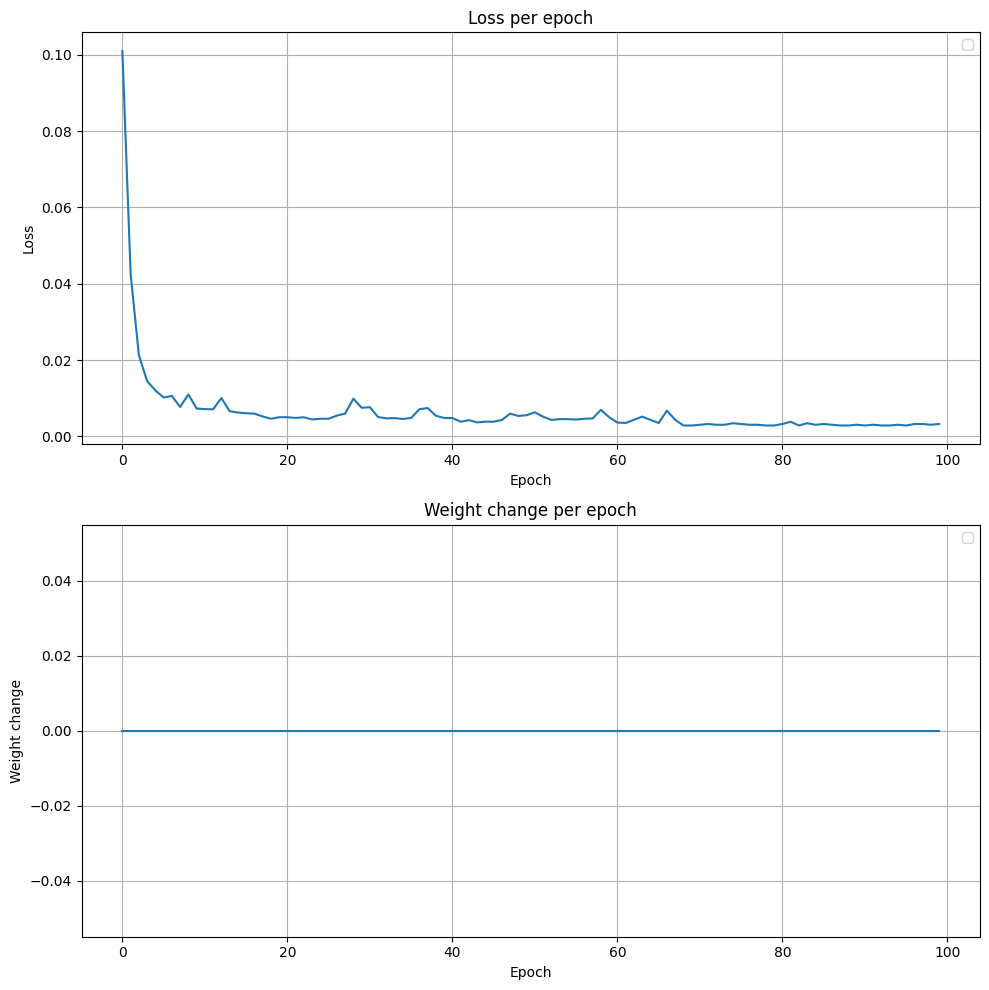

In [66]:
model = train_NNet(train_X_1_5, train_y_1_5, epochs= 100, eta = 0.001)

## Section 3: Evaluation using test data

The following function will evaluate then return an accuracy score and the predicted labels for your model. Do not change anything here.

In [67]:
def test_model(test_data, test_labels, model, d1, d2):
    
    L = len(model.hidden_layers) + 1
    
    Y = test_data
    for i in range(L):
        Z = np.matmul(model.W[i], np.append(Y, np.array([np.ones(Y.shape[1])]), axis = 0))
        if i < L - 1:
            Y = ReLu(Z)
        else:
            Y = sigmoid(Z)
    
    Y = Y[0]
    Y = np.where(Y >= 0.5, 1, 0)
    Y_predicted = np.where(Y == 0, d1, d2)

    acc = accuracy_score(test_labels, Y_predicted)

    return(acc, Y_predicted)

    

**Q10.** Use this test_model function to evaluate your model with the $1$ and $5$ digits. An accuracy $>= 99%$ is achievable. Test with different batch sizes, $\eta$ values and hidden layers. Find which of those hyperparameters gives the best test accuracy. <font color='blue'>Document the hyperparameter values that gives the best testing accuracy and that best accuracy. Plot a confusion matrix and comment on your observations with reasons. Also, look into the nature of the plots that result fom the training procedure, see how they vary with the hyperparameters and provide your ideas on the observations. Then do the same with a few other pairs of digits $d_1, d_2$. Especially, try $d_1 = 1, d_2 = 7$. Comment on your observations and explain possible reasons</font>.

In [68]:
accuracy,predict_y = test_model(test_X_1_5, test_y_1_5, model, 1, 5)
predict_y

array([1, 1, 5, ..., 1, 5, 1])

In [69]:
predict_y = np.where(predict_y > 1, 1, predict_y)


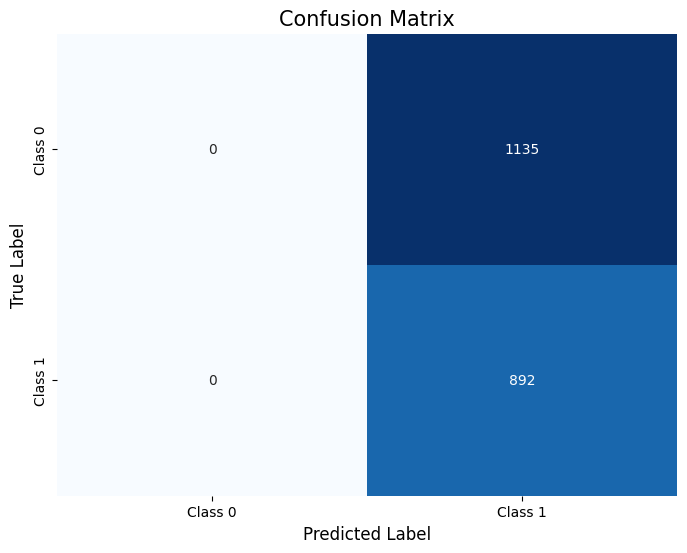

In [70]:
from sklearn.metrics import confusion_matrix  
import seaborn as sns  
import pandas as pd  
import matplotlib.pyplot as plt  

# Generate confusion matrix
cm = confusion_matrix(y_true=test_y_1_5, y_pred=predict_y)

# Convert the confusion matrix to a DataFrame for easier plotting
cm_df = pd.DataFrame(cm, 
                     index=['Class 0', 'Class 1'],    
                     columns=['Class 0', 'Class 1'])  #

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))  # Set figure size
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])  # Create heatmap

# Customize the plot
plt.title('Confusion Matrix', fontsize=15)  
plt.xlabel('Predicted Label', fontsize=12)  
plt.ylabel('True Label', fontsize=12)       #

plt.show()
